In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Optimizasyon Algoritmaları Matematiği")
print("=" * 40)
print()
print("Bugün işleyeceklerimiz:")
print("1. SGD — en temel optimizer")
print("2. Momentum — geçmişi hatırla")
print("3. RMSProp — adaptif learning rate")
print("4. Adam — momentum + RMSProp")
print("5. Hepsini aynı problemde karşılaştır")
print()
print("Soru: Neden Adam bu kadar popüler?")
print("Cevabı matematikte!")

np.random.seed(42)

Optimizasyon Algoritmaları Matematiği

Bugün işleyeceklerimiz:
1. SGD — en temel optimizer
2. Momentum — geçmişi hatırla
3. RMSProp — adaptif learning rate
4. Adam — momentum + RMSProp
5. Hepsini aynı problemde karşılaştır

Soru: Neden Adam bu kadar popüler?
Cevabı matematikte!


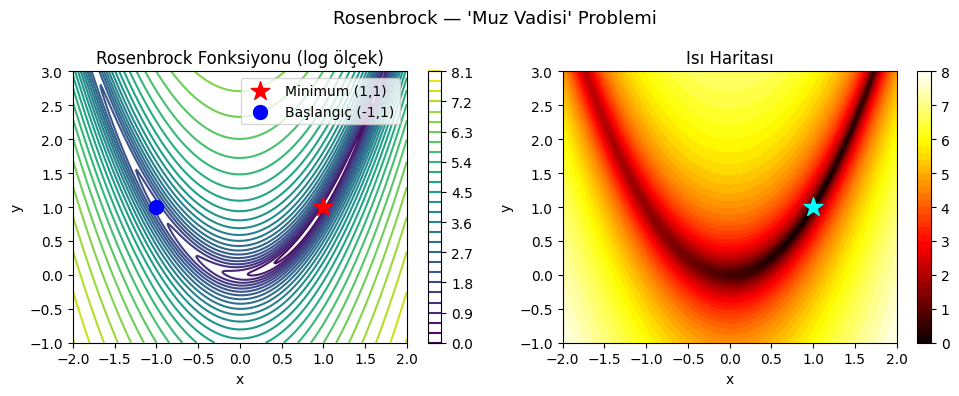

Minimum nokta: f(1,1) = 0
Başlangıç:     f(-1,1) = 4.0


In [2]:
# Test fonksiyonu: Rosenbrock — optimizasyon algoritmalarının klasik test problemi
# f(x,y) = (1-x)² + 100(y-x²)²
# Minimum: (1, 1) — bulmak çok zor!

def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    dx = -2*(1-x) - 400*x*(y - x**2)
    dy = 200*(y - x**2)
    return np.array([dx, dy])

# Görselleştir
x_range = np.linspace(-2, 2, 300)
y_range = np.linspace(-1, 3, 300)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock(X, Y)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.contour(X, Y, np.log(Z + 1), levels=30, cmap='viridis')
plt.colorbar()
plt.scatter([1], [1], color='red', s=200, zorder=5, marker='*', label='Minimum (1,1)')
plt.scatter([-1], [1], color='blue', s=100, zorder=5, label='Başlangıç (-1,1)')
plt.title("Rosenbrock Fonksiyonu (log ölçek)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1, 2, 2)
plt.contourf(X, Y, np.log(Z + 1), levels=50, cmap='hot')
plt.colorbar()
plt.scatter([1], [1], color='cyan', s=200, zorder=5, marker='*')
plt.title("Isı Haritası")
plt.xlabel("x")
plt.ylabel("y")

plt.suptitle("Rosenbrock — 'Muz Vadisi' Problemi", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Minimum nokta: f(1,1) = {rosenbrock(1,1)}")
print(f"Başlangıç:     f(-1,1) = {rosenbrock(-1,1):.1f}")

In [3]:
# 1. SGD — Stochastic Gradient Descent
# w = w - lr * grad
# Basit ama yavaş, learning rate seçimi kritik

def sgd(grad_fn, start, lr=0.001, steps=10000):
    x, y = start
    history = [(x, y)]
    
    for _ in range(steps):
        grad = grad_fn(x, y)
        x = x - lr * grad[0]
        y = y - lr * grad[1]
        history.append((x, y))
    
    return np.array(history)

# 2. Momentum
# v = beta*v - lr*grad
# w = w + v
# Geçmiş gradyanları hatırlar, salınımı azaltır

def momentum(grad_fn, start, lr=0.001, beta=0.9, steps=10000):
    x, y = start
    vx, vy = 0, 0
    history = [(x, y)]
    
    for _ in range(steps):
        grad = grad_fn(x, y)
        vx = beta * vx - lr * grad[0]
        vy = beta * vy - lr * grad[1]
        x = x + vx
        y = y + vy
        history.append((x, y))
    
    return np.array(history)

# 3. RMSProp
# s = beta*s + (1-beta)*grad²
# w = w - lr * grad / sqrt(s + eps)
# Her parametrenin learning rate'ini ayrı ayarlar

def rmsprop(grad_fn, start, lr=0.001, beta=0.9, eps=1e-8, steps=10000):
    x, y = start
    sx, sy = 0, 0
    history = [(x, y)]
    
    for _ in range(steps):
        grad = grad_fn(x, y)
        sx = beta * sx + (1-beta) * grad[0]**2
        sy = beta * sy + (1-beta) * grad[1]**2
        x = x - lr * grad[0] / (np.sqrt(sx) + eps)
        y = y - lr * grad[1] / (np.sqrt(sy) + eps)
        history.append((x, y))
    
    return np.array(history)

# 4. Adam — Adaptive Moment Estimation
# m = beta1*m + (1-beta1)*grad        ← 1. moment (momentum)
# v = beta2*v + (1-beta2)*grad²       ← 2. moment (RMSProp)
# m̂ = m / (1-beta1^t)                ← bias correction
# v̂ = v / (1-beta2^t)                ← bias correction
# w = w - lr * m̂ / (sqrt(v̂) + eps)

def adam(grad_fn, start, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, steps=10000):
    x, y = start
    mx, my = 0, 0
    vx, vy = 0, 0
    history = [(x, y)]
    
    for t in range(1, steps+1):
        grad = grad_fn(x, y)
        
        # 1. moment güncelle
        mx = beta1 * mx + (1-beta1) * grad[0]
        my = beta1 * my + (1-beta1) * grad[1]
        
        # 2. moment güncelle
        vx = beta2 * vx + (1-beta2) * grad[0]**2
        vy = beta2 * vy + (1-beta2) * grad[1]**2
        
        # Bias correction — başlangıçta sıfıra yakın olduğu için
        mx_hat = mx / (1 - beta1**t)
        my_hat = my / (1 - beta2**t)
        vx_hat = vx / (1 - beta2**t)
        vy_hat = vy / (1 - beta2**t)
        
        # Güncelle
        x = x - lr * mx_hat / (np.sqrt(vx_hat) + eps)
        y = y - lr * my_hat / (np.sqrt(vy_hat) + eps)
        history.append((x, y))
    
    return np.array(history)

print("Tüm optimizerlar tanımlandı!")
print("Şimdi aynı başlangıç noktasından koşturalım...")

start = (-1.0, 1.0)
steps = 5000

sgd_hist      = sgd(rosenbrock_grad, start, lr=0.001, steps=steps)
momentum_hist = momentum(rosenbrock_grad, start, lr=0.001, steps=steps)
rmsprop_hist  = rmsprop(rosenbrock_grad, start, lr=0.001, steps=steps)
adam_hist     = adam(rosenbrock_grad, start, lr=0.01, steps=steps)

print("\nSon noktalara ulaşıldı:")
for isim, hist in [("SGD", sgd_hist), ("Momentum", momentum_hist),
                    ("RMSProp", rmsprop_hist), ("Adam", adam_hist)]:
    son = hist[-1]
    loss = rosenbrock(son[0], son[1])
    print(f"{isim:10s} → ({son[0]:.4f}, {son[1]:.4f}) | Loss: {loss:.6f}")

Tüm optimizerlar tanımlandı!
Şimdi aynı başlangıç noktasından koşturalım...

Son noktalara ulaşıldı:
SGD        → (0.9398, 0.8830) | Loss: 0.003627
Momentum   → (1.0000, 1.0000) | Loss: 0.000000
RMSProp    → (0.9928, 0.9870) | Loss: 0.000269
Adam       → (0.9999, 0.9998) | Loss: 0.000000


In [4]:
# Her optimizer'ın matematiksel formülü
print("=" * 55)
print("OPTİMİZER MATEMATİĞİ")
print("=" * 55)

print("""
1. SGD (Stochastic Gradient Descent)
─────────────────────────────────────
w = w - lr * dL/dw

Sorun: Her adım sadece anlık gradyana bakıyor.
       Dar vadilerde zikzak yapıyor, yavaş ilerliyor.

2. MOMENTUM
─────────────────────────────────────
v = β*v + (1-β)*dL/dw     ← hız (velocity)
w = w - lr * v

β genellikle 0.9 — geçmiş gradyanların %90'ını hatırla.
Sezgi: Topun yokuştan aşağı yuvarlanması gibi.
       Zikzak azalır, ivme kazanır.

3. RMSProp
─────────────────────────────────────
s = β*s + (1-β)*(dL/dw)²  ← gradyan karesi ortalaması
w = w - lr * dL/dw / (√s + ε)

Sezgi: Büyük gradyanlarda adımı küçült,
       küçük gradyanlarda büyüt.
       Her parametre için farklı lr!

4. ADAM (Adaptive Moment Estimation)
─────────────────────────────────────
m = β1*m + (1-β1)*dL/dw         ← 1. moment (momentum)
v = β2*v + (1-β2)*(dL/dw)²      ← 2. moment (RMSProp)

m̂ = m / (1-β1^t)                ← bias düzeltme
v̂ = v / (1-β2^t)                ← bias düzeltme

w = w - lr * m̂ / (√v̂ + ε)

β1=0.9, β2=0.999, ε=1e-8 (varsayılan)
Adam = Momentum + RMSProp + Bias düzeltme
""")

OPTİMİZER MATEMATİĞİ

1. SGD (Stochastic Gradient Descent)
─────────────────────────────────────
w = w - lr * dL/dw

Sorun: Her adım sadece anlık gradyana bakıyor.
       Dar vadilerde zikzak yapıyor, yavaş ilerliyor.

2. MOMENTUM
─────────────────────────────────────
v = β*v + (1-β)*dL/dw     ← hız (velocity)
w = w - lr * v

β genellikle 0.9 — geçmiş gradyanların %90'ını hatırla.
Sezgi: Topun yokuştan aşağı yuvarlanması gibi.
       Zikzak azalır, ivme kazanır.

3. RMSProp
─────────────────────────────────────
s = β*s + (1-β)*(dL/dw)²  ← gradyan karesi ortalaması
w = w - lr * dL/dw / (√s + ε)

Sezgi: Büyük gradyanlarda adımı küçült,
       küçük gradyanlarda büyüt.
       Her parametre için farklı lr!

4. ADAM (Adaptive Moment Estimation)
─────────────────────────────────────
m = β1*m + (1-β1)*dL/dw         ← 1. moment (momentum)
v = β2*v + (1-β2)*(dL/dw)²      ← 2. moment (RMSProp)

m̂ = m / (1-β1^t)                ← bias düzeltme
v̂ = v / (1-β2^t)                ← bias düzeltme

w =

In [5]:
# Her optimizer'ı sıfırdan implement et
class SGD:
    def __init__(self, lr=0.001):
        self.lr = lr

    def step(self, params, grads):
        return params - self.lr * grads

class Momentum:
    def __init__(self, lr=0.001, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.v = None

    def step(self, params, grads):
        if self.v is None:
            self.v = np.zeros_like(grads)
        self.v = self.beta * self.v + (1 - self.beta) * grads
        return params - self.lr * self.v

class RMSProp:
    def __init__(self, lr=0.001, beta=0.9, eps=1e-8):
        self.lr = lr
        self.beta = beta
        self.eps = eps
        self.s = None

    def step(self, params, grads):
        if self.s is None:
            self.s = np.zeros_like(grads)
        self.s = self.beta * self.s + (1 - self.beta) * grads**2
        return params - self.lr * grads / (np.sqrt(self.s) + self.eps)

class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0

    def step(self, params, grads):
        if self.m is None:
            self.m = np.zeros_like(grads)
            self.v = np.zeros_like(grads)
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads
        self.v = self.beta2 * self.v + (1 - self.beta2) * grads**2
        # Bias düzeltme
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        return params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# Tüm optimizer'ları çalıştır
başlangıç = np.array([-1.0, 1.0])
n_adım = 2000

optimizerlar = {
    'SGD':      SGD(lr=0.001),
    'Momentum': Momentum(lr=0.001, beta=0.9),
    'RMSProp':  RMSProp(lr=0.001, beta=0.9),
    'Adam':     Adam(lr=0.001, beta1=0.9, beta2=0.999)
}

renkler = {'SGD': 'red', 'Momentum': 'blue', 'RMSProp': 'green', 'Adam': 'purple'}
sonuçlar = {}

for isim, optimizer in optimizerlar.items():
    params = başlangıç.copy()
    yol = [params.copy()]
    kayıplar = []

    for _ in range(n_adım):
        grad = rosenbrock_grad(params[0], params[1])
        params = optimizer.step(params, grad)
        params = np.clip(params, -2, 3)
        yol.append(params.copy())
        kayıplar.append(rosenbrock(params[0], params[1]))

    sonuçlar[isim] = {
        'yol': np.array(yol),
        'kayıplar': kayıplar,
        'son': params
    }
    print(f"{isim:10s} → ({params[0]:.4f}, {params[1]:.4f}) | Loss: {kayıplar[-1]:.6f}")

SGD        → (0.7279, 0.5286) | Loss: 0.074176
Momentum   → (0.7291, 0.5304) | Loss: 0.073534
RMSProp    → (0.7358, 0.5412) | Loss: 0.069789
Adam       → (0.6501, 0.4206) | Loss: 0.122826


In [6]:
başlangıç = np.array([-1.0, 1.0])
n_adım = 5000

optimizerlar = {
    'SGD':      SGD(lr=0.0001),
    'Momentum': Momentum(lr=0.0001, beta=0.9),
    'RMSProp':  RMSProp(lr=0.001, beta=0.9),
    'Adam':     Adam(lr=0.01, beta1=0.9, beta2=0.999)
}

renkler = {'SGD': 'red', 'Momentum': 'blue', 'RMSProp': 'green', 'Adam': 'purple'}
sonuçlar = {}

for isim, optimizer in optimizerlar.items():
    params = başlangıç.copy()
    yol = [params.copy()]
    kayıplar = []

    for _ in range(n_adım):
        grad = rosenbrock_grad(params[0], params[1])
        # Gradyan patlamasını önle
        grad = np.clip(grad, -10, 10)
        params = optimizer.step(params, grad)
        params = np.clip(params, -2, 3)
        yol.append(params.copy())
        kayıplar.append(rosenbrock(params[0], params[1]))

    sonuçlar[isim] = {
        'yol': np.array(yol),
        'kayıplar': kayıplar,
        'son': params
    }
    print(f"{isim:10s} → ({params[0]:.4f}, {params[1]:.4f}) | Loss: {kayıplar[-1]:.8f}")

SGD        → (-0.4464, 0.2065) | Loss: 2.09718513
Momentum   → (-0.4481, 0.2080) | Loss: 2.10214757
RMSProp    → (0.9928, 0.9870) | Loss: 0.00026896
Adam       → (0.9999, 0.9998) | Loss: 0.00000026


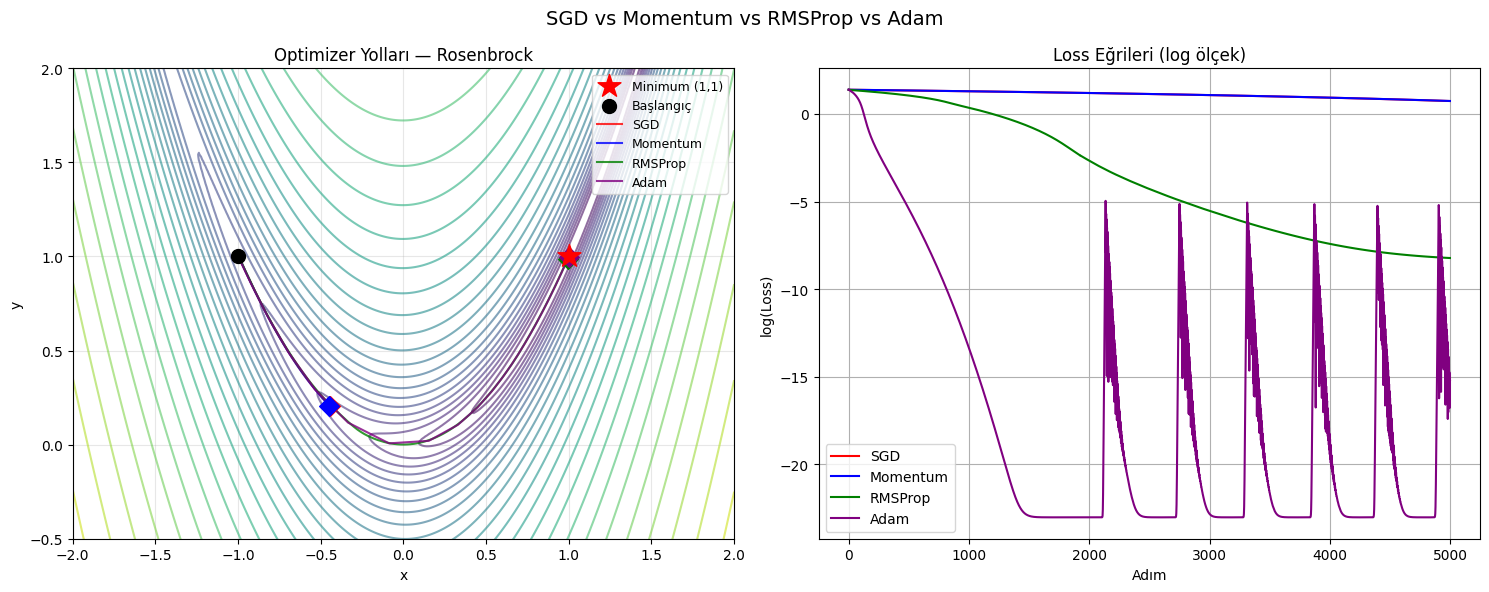

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Sol — Yollar
ax = axes[0]
contour = ax.contour(X, Y, np.log(Z + 1), levels=30, cmap='viridis', alpha=0.6)
ax.scatter([1], [1], color='red', s=300, zorder=10, marker='*', label='Minimum (1,1)')
ax.scatter([-1], [1], color='black', s=100, zorder=10, marker='o', label='Başlangıç')

for isim, sonuç in sonuçlar.items():
    yol = sonuç['yol']
    # Her 50 adımda bir çiz
    ax.plot(yol[::20, 0], yol[::20, 1],
            color=renkler[isim], linewidth=1.5,
            label=isim, alpha=0.8)
    # Son noktayı işaretle
    ax.scatter(yol[-1, 0], yol[-1, 1],
               color=renkler[isim], s=100, zorder=9, marker='D')

ax.set_xlim(-2, 2)
ax.set_ylim(-0.5, 2)
ax.set_title("Optimizer Yolları — Rosenbrock", fontsize=12)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Sağ — Loss eğrileri
ax2 = axes[1]
for isim, sonuç in sonuçlar.items():
    kayıplar = sonuç['kayıplar']
    ax2.plot(np.log(np.array(kayıplar) + 1e-10),
             color=renkler[isim], linewidth=1.5, label=isim)

ax2.set_title("Loss Eğrileri (log ölçek)", fontsize=12)
ax2.set_xlabel("Adım")
ax2.set_ylabel("log(Loss)")
ax2.legend()
ax2.grid(True)

plt.suptitle("SGD vs Momentum vs RMSProp vs Adam", fontsize=14)
plt.tight_layout()
plt.show()

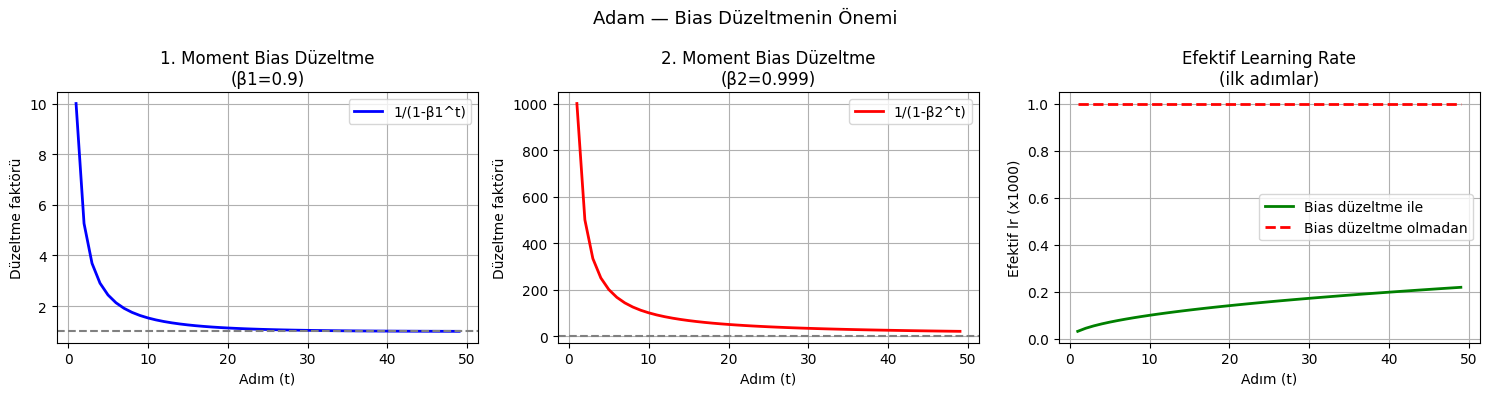

İlk adımda bias düzeltme olmadan m ve v sıfıra yakın başlar
Bu da efektif learning rate'i yapay olarak küçültür
Bias düzeltme bu sorunu ortadan kaldırır!


In [8]:
# ADAM'IN BIAS DÜZELTMESİ — Neden şart?

t_values = np.arange(1, 50)
beta1 = 0.9
beta2 = 0.999

# Bias düzeltme faktörleri
bias1 = 1 - beta1**t_values  # 1. moment
bias2 = 1 - beta2**t_values  # 2. moment

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. moment bias
axes[0].plot(t_values, 1/bias1, 'b-', linewidth=2, label='1/(1-β1^t)')
axes[0].axhline(y=1, color='gray', linestyle='--')
axes[0].set_title("1. Moment Bias Düzeltme\n(β1=0.9)")
axes[0].set_xlabel("Adım (t)")
axes[0].set_ylabel("Düzeltme faktörü")
axes[0].legend()
axes[0].grid(True)

# 2. moment bias
axes[1].plot(t_values, 1/bias2, 'r-', linewidth=2, label='1/(1-β2^t)')
axes[1].axhline(y=1, color='gray', linestyle='--')
axes[1].set_title("2. Moment Bias Düzeltme\n(β2=0.999)")
axes[1].set_xlabel("Adım (t)")
axes[1].set_ylabel("Düzeltme faktörü")
axes[1].legend()
axes[1].grid(True)

# Eğer bias düzeltme olmasa — ilk adımlarda lr çok küçük olur
lr = 0.001
efektif_lr_ile = lr / (np.sqrt(1/bias2) + 1e-8)
efektif_lr_olmadan = np.full_like(t_values, lr, dtype=float)

axes[2].plot(t_values, efektif_lr_ile * 1000, 'g-',
             linewidth=2, label='Bias düzeltme ile')
axes[2].plot(t_values, efektif_lr_olmadan * 1000, 'r--',
             linewidth=2, label='Bias düzeltme olmadan')
axes[2].set_title("Efektif Learning Rate\n(ilk adımlar)")
axes[2].set_xlabel("Adım (t)")
axes[2].set_ylabel("Efektif lr (x1000)")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Adam — Bias Düzeltmenin Önemi", fontsize=13)
plt.tight_layout()
plt.show()

print("İlk adımda bias düzeltme olmadan m ve v sıfıra yakın başlar")
print("Bu da efektif learning rate'i yapay olarak küçültür")
print("Bias düzeltme bu sorunu ortadan kaldırır!")